In [2]:
!pip3.10 install sktime

/bin/bash: line 1: pip3.10: command not found


# Гипотеза 
Выдвинем следующую гипотезу: 

Различные преобразования по-разному влияют на качество прогнозирования для разных типов рядов. 

В ходе проверки гипотезы будут использованы следующие преобразований: 
- Log1p преобразования;
- Box-Cox;
- Differencing.

Целью исследования является выяснение эффектов, производимых указанными преобразованиями на различные временные ряды, и сравнение качества предсказаний. 

## План работы: 
1. EDA
2. Построение бейзлайнов (Naive и Seasonal Naive)
3. Кластеризация рядов методом TimeSeriesKMeans
4. Фиксирование глобальной модели (CatBoost)
5. Применение различных трансформаций и сравнение полученных эффектов
6. Анализ по кластерам 


# Первичная работа с данными

## Загрузка данных

В качестве датасета выбран М4 monthly. 



In [56]:
import pandas as pd
import numpy as np
from src.data_loader import load_data
from src.data_loader import select_n_series
from src.data_loader import split_data
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = load_data()

In [5]:
df.head() 

series_value
series_name timestamp                        
T1          1976-06-01 12:00:00        8000.0
            1976-07-01 12:00:00        8350.0
            1976-08-01 12:00:00        8570.0
            1976-09-01 12:00:00        7700.0
            1976-10-01 12:00:00        7080.0

Выделим 200 рядов. 

In [6]:
df = select_n_series(df, 200)

In [7]:
df["series_name"].nunique()

200

In [8]:
df.head()

,series_name,timestamp,series_value
0,T1,1976-06-01 12:00:00,8000.0
1,T1,1976-07-01 12:00:00,8350.0
2,T1,1976-08-01 12:00:00,8570.0
3,T1,1976-09-01 12:00:00,7700.0
4,T1,1976-10-01 12:00:00,7080.0


In [9]:
df.shape

(80149, 3)

Посмотрим базовые статистики

In [18]:
print(df['series_value'].describe())

count    80149.000000
mean      4115.913641
std       4192.748204
min        115.590000
25%       1252.560000
50%       2438.410000
75%       5650.000000
max      55260.000000
Name: series_value, dtype: float64


Статистика по длине рядов

In [19]:
series_lengths = df.groupby('series_name').size()
print(f"\nДлина рядов:")
print(f"Минимальная: {series_lengths.min()}")
print(f"Максимальная: {series_lengths.max()}")
print(f"Средняя: {series_lengths.mean():.0f}")
print(f"Медианная: {series_lengths.median():.0f}")


Длина рядов:
Минимальная: 82
Максимальная: 1248
Средняя: 401
Медианная: 379


Проверка на пропуски в данных

In [35]:
print(f"Пропуски в данных: {df['series_value'].isnull().sum()}")
df.isna().sum()

Пропуски в данных: 0


series_name     0
timestamp       0
series_value    0
dtype: int64

Проверка на дубли в данных

In [36]:
print(f"Дубли в данных: {int(df.duplicated().sum())}")

Дубли в данных: 0


Перед разбиением посмотрим длины рядов. 

In [20]:
pd.set_option('display.max_rows', None)

In [11]:
df.groupby("series_name").size()

series_name
T1       487
T10      384
T100     310
T101     262
T102     262
T103     185
T104     157
T105     439
T106      91
T107     187
T108     187
T109      85
T11      636
T110      85
T111      85
T112      85
T113     187
T114     840
T115     439
T116     439
T117     840
T118     840
T119     840
T12      936
T120     840
T121     840
T122    1248
T123     840
T124     301
T125     840
T126     301
T127     301
T128     301
T129     301
T13      936
T130     306
T131      86
T132      86
T133      86
T134      86
T135      86
T136      86
T137      86
T138     504
T139     504
T14      744
T140     504
T141     175
T142     349
T143     175
T144     391
T145    1092
T146     504
T147      94
T148     840
T149     840
T15      744
T150     840
T151     840
T152     600
T153      86
T154      86
T155      86
T156     600
T157     516
T158     840
T159     516
T16      744
T160      91
T161      97
T162      97
T163     247
T164     247
T165     127
T166     837
T167      82


Видим, что длины у рядов различаются - в диапазоне от 82 точек до 1248. Тем не менее, это все еще позволяет разбить ряды на train и test таким образом, чтобы в test попало фиксированное число точек. 

Посмотрим на распределение значений

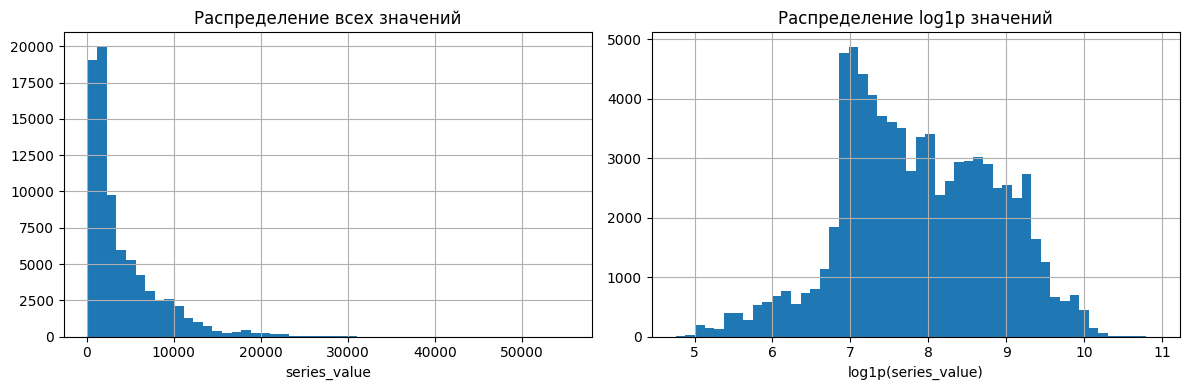

In [23]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['series_value'].hist(bins=50)
plt.title('Распределение всех значений')
plt.xlabel('series_value')

plt.subplot(1, 2, 2)

np.log1p(df['series_value']).hist(bins=50)
plt.title('Распределение log1p значений')
plt.xlabel('log1p(series_value)')

plt.tight_layout()
plt.show()

**Выводы:** 
1) Распределение целевой переменной  
- Сильная правосторонняя асимметрия: среднее (4116) сильно больше медианы (2438)
- Большой разброс: от 115 до 55,260 (размах в 480 раз)
- Лог-трансформация явно будет полезна (гистограмма log1p выглядит более нормальной)

2) Разная длина рядов (может повлиять на кластеризацию)  
- Минимум: 82 точки
- Максимум: 1248 точек
- Медиана: 379 точек

## Train-test разбиение

Применим разбиение с фиксированным временным горизонтом. Для начала проанализируем, возможно ли произвести разбиение на train и test следующим образом: из 487 строк каждого ряда добавим 20 в test, а остальное оставим в train.

Проверим, действительно ли длина всех рядов позволит взять 20 точек в тест

In [27]:
# проверка на самом коротком ряду
series_lengths = df.groupby('series_name').size()
min_length = series_lengths.min()
print(f"\nСамый короткий ряд имеет {min_length} точки")
print(f"При горизонте 20, в тест уйдет {20/min_length:.1%} данных")
print(f"Train останется: {min_length - 20} точек")


Самый короткий ряд имеет 82 точки
При горизонте 20, в тест уйдет 24.4% данных
Train останется: 62 точек


In [28]:
# оценка пропорции train/test для различных рядов
test_fractions = []
for series_name in df['series_name'].unique():
    series_data = df[df['series_name'] == series_name]
    total_points = len(series_data)
    test_fraction = 20 / total_points
    test_fractions.append(test_fraction)

print(f"\nАнализ доли тестовой выборки (горизонт в 20 точек):")
print(f"Минимальная доля теста: {min(test_fractions):.1%} (у самого длинного ряда)")
print(f"Максимальная доля теста: {max(test_fractions):.1%} (у самого короткого ряда)") 
print(f"Средняя доля теста: {np.mean(test_fractions):.1%}")
print(f"Медианная доля теста: {np.median(test_fractions):.1%}")


Анализ доли тестовой выборки (горизонт в 20 точек):
Минимальная доля теста: 1.6% (у самого длинного ряда)
Максимальная доля теста: 24.4% (у самого короткого ряда)
Средняя доля теста: 8.4%
Медианная доля теста: 5.3%


**Выводы:** При разбиении временных рядов на обучающую и тестовую выборки мы можем использовать фиксированный горизонт прогнозирования: для каждого ряда последние 20 точек берем в тест, а все предыдущие остаются в обучении. Даже для самого короткого ряда с 82 точками в обучении остаётся 62 точки, чего, на наш взгляд, достаточно для построения модели. В результате получили 76 149 наблюдений в train и 4 000 в test, при этом доля теста варьируется от 1.6% до 24.4% в зависимости от длины ряда.



In [29]:
df_train, df_test = split_data(df, horizon=20)

In [30]:
df_train.shape

(76149, 3)

In [31]:
df_test.shape

(4000, 3)

## EDA
### Построим графики

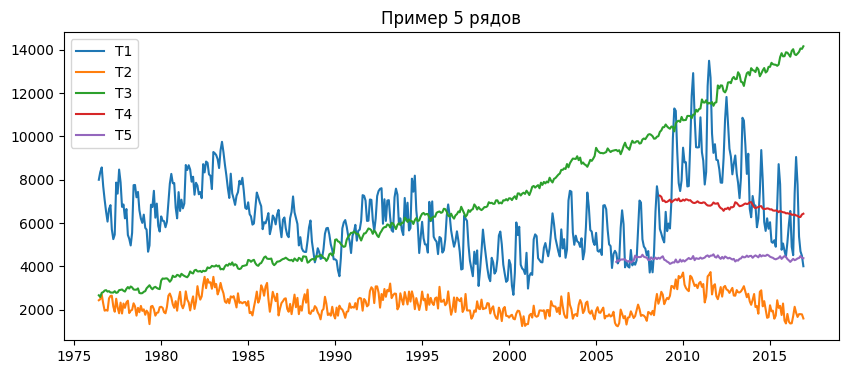

In [15]:
sample = df["series_name"].unique()[:5]
fig, axes = plt.subplots(figsize=(10, 4))
for s in sample: 
    subset = df[df["series_name"] == s]
    plt.plot(subset["timestamp"], subset["series_value"], label=s)

plt.title('Пример 5 рядов')
plt.legend()
plt.show()

На графике видно, что ряды сильно отличаются не только по длине, но и по компонентам ряда: для многих из представленных рядов можно выделить тренд, сезонность, а также можно отметить разницу в дисперсии. 

Таким образом, первичный визуальный анализ позволяет сделать следующие выводы для первыз пяти рядов (Т1-Т5):
- Т1: Видим длинные циклы длиной приблизительно в 10 лет, а также более мелкие циклы приблизительно в 1 год. Выделяется мультипликативная сезонность.
- Т2: На первый взгляд, не выделяется тренд или сезонность. Ряд выглядит так, словно колеблется вокруг некоторого среднего значения, ожнако стоит произвести дополнительное исследование относительно циклов. Дисперсия постоянна во времени. 
- Т3: Отчетливый восходящий тренд. Дисперсия меньше. 
- Т4: Виден плавный нисходящий тренд. Дисперсия аддитивная, небольшая.
- Т5: Нельзя выделить тренд или циклы. Дисперсия аддитивная, небольшая. 

# Бейзлайны

Далее рассмотрим два простейших бейзлайна: Naive и Seasonal Naive. 

Выбор бейзлайнов обусловлен простотой, а также разнообразием рядов датасета. Таким образом, Naive будет представлять простейший примитивный бейзлайн, универсальный для всех рядов, а Seasonal Naive будет показателен для исследования сравнения рядов с выраженной сезонностью. 

Напомним общую информацию по рассматриваемым бейзлайнам. 

### Naive model 
Следующее значение будет равняться предыдущему значнию ряда. Другими словами: 
$$ \hat{y}_{t+h} = y_t $$


### Seasonal Naive model 
Следующее значение будет равняться аналогичному значению предыдущего цикла. Другими словами: 

$ \hat{y}_{t+h} = y_{t+h-s}$, где $s$ - длина сезона/цикла. Учтем, что в рассматриваемом датасете $s=12$. Построим графики прогнозов для выбранных ранее в процессе EDA рядов.



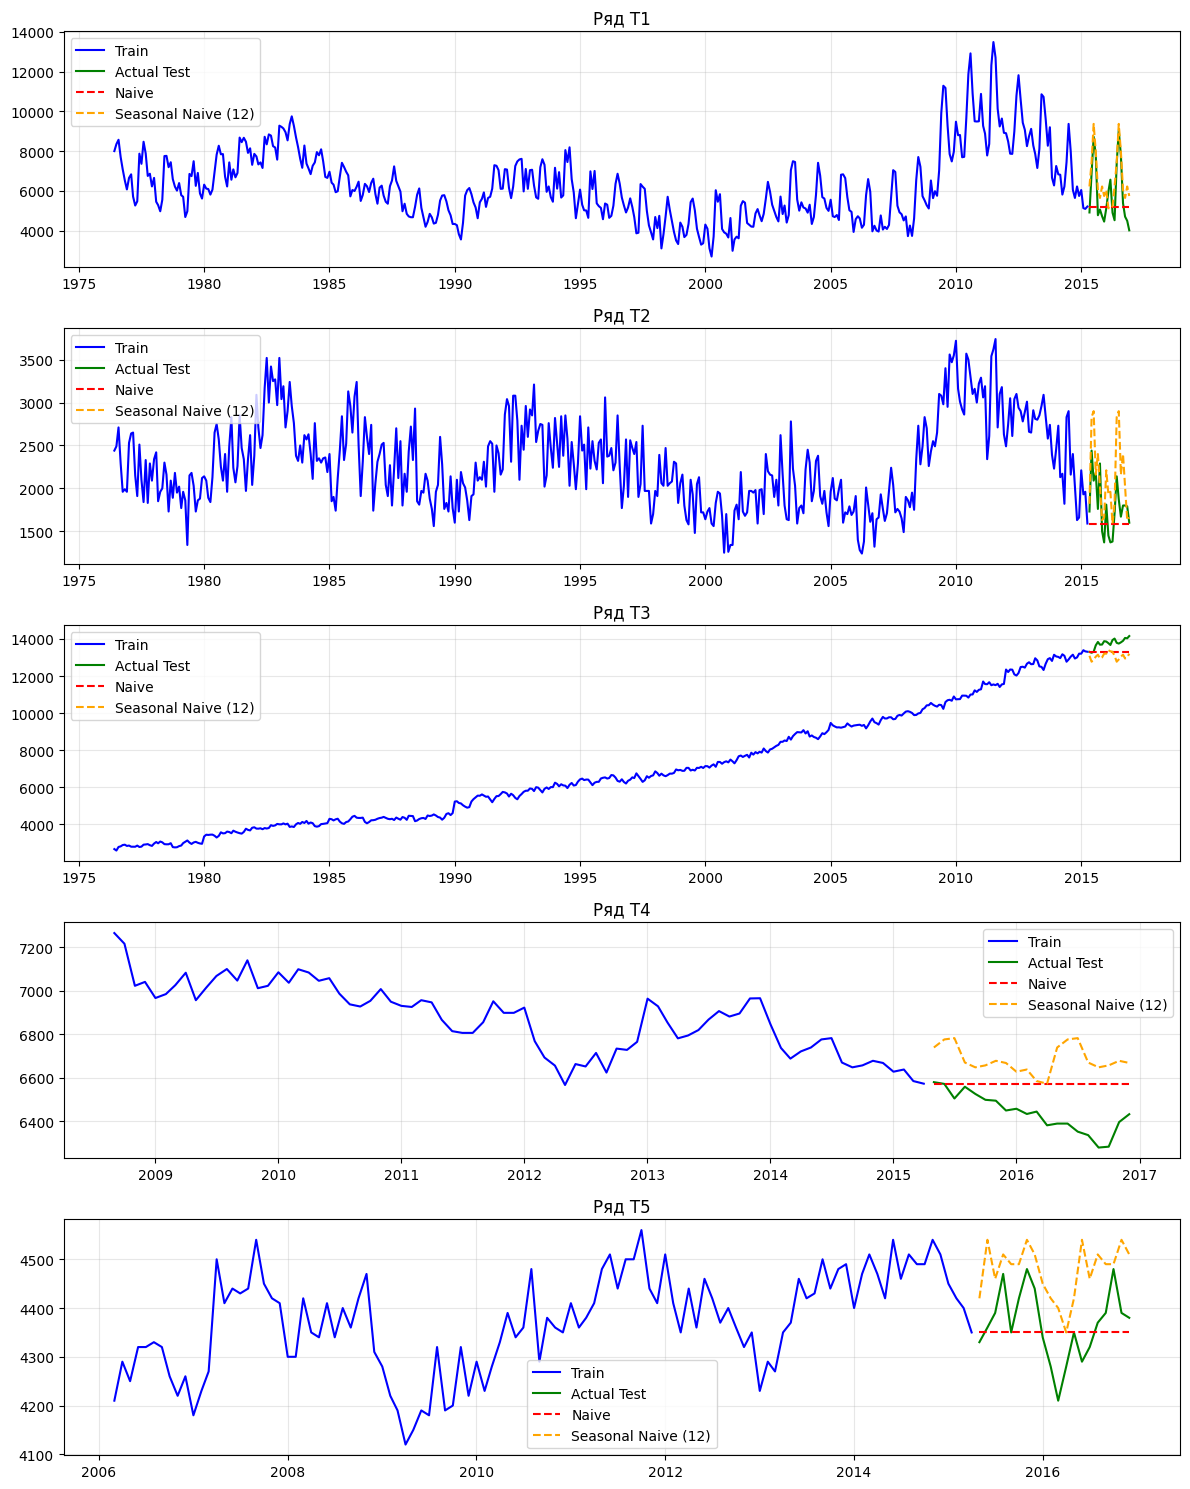

In [38]:
fig, axes = plt.subplots(len(sample), 1, figsize=(12, 15))
for idx, series_name in enumerate(sample):

    df_train_series_data = df_train[df_train['series_name'] == series_name]
    df_test_series_data = df_test[df_test['series_name'] == series_name]

    naive_pred = [df_train_series_data['series_value'].iloc[-1]] * 20
    
    seasonal_pred = []
    for i in range(20):
        lag = 12 - (i % 12)
        seasonal_pred.append(df_train_series_data['series_value'].iloc[-lag])
    
    axes[idx].plot(df_train_series_data['timestamp'], df_train_series_data['series_value'], label='Train', color='blue')
    axes[idx].plot(df_test_series_data['timestamp'], df_test_series_data['series_value'], label='Actual Test', color='green')
    axes[idx].plot(df_test_series_data['timestamp'], naive_pred, '--', label='Naive', color='red')
    axes[idx].plot(df_test_series_data['timestamp'], seasonal_pred, '--', label='Seasonal Naive (12)', color='orange')
    axes[idx].set_title(f'Ряд {series_name}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Метрики
В качестве метрик будем использовать MAE и SMAPE. Обоснование выбора:  
1) MAE — показывает абсолютную ошибку в натуральных единицах
MAE = mean(|y_true - y_pred|)
- Простая и легко интерпретируемая метрика (поскольку возвращается в тех же единицах измерения, что и данные)
- Менее чувствительна к выбросам, чем MSE/RMSE

2) SMAPE — позволяет корректно усреднять ошибки по рядам с разными масштабами
SMAPE = 200% * mean(|y_true - y_pred| / (|y_true| + |y_pred|))
- более симметрична, чем MAPE (штраф для занижения и завышения одинаковый)
- позволяет сравнивать ряды с разным масштабом
- ограничена сверху (0 - 200%)

Резюме: в то время, как MAE показывает абсолютную ошибку, метрика SMAPE показывает относительную ошибку, что позволяет корректно оценивать ряды из рассматриваемого датасета. Ряды в датасете очень различны (значения колеблются от 115 до 55 260), и SMAPE поможет выстроить корректную схему оценивания качества преобразований рядов.  

In [40]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive
from src.metrics import smape
from sklearn.metrics import mean_absolute_error

/home/crow0/ts_project/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
df_train_copy = df_train.copy()

df_train_copy = df_train_copy.rename(columns={
    "series_name": "unique_id",
    "timestamp": "ds",
    "series_value": "y"
})

In [42]:
df_test_copy = df_test.copy()

df_test_copy = df_test_copy.rename(columns={
    "series_name": "unique_id",
    "timestamp": "ds",
    "series_value": "y"
})

In [43]:
sf = StatsForecast(
    models = [
        Naive(),
        SeasonalNaive(season_length=12)
    ],
    freq='MS',
    verbose=True
)
sf.fit(df_train_copy)
preds = sf.predict(h=20)

In [44]:
preds.head()

,unique_id,ds,Naive,SeasonalNaive
0,T1,2015-05-01 12:00:00,5210.0,6220.0
1,T1,2015-06-01 12:00:00,5210.0,7450.0
2,T1,2015-07-01 12:00:00,5210.0,9370.0
3,T1,2015-08-01 12:00:00,5210.0,7980.0
4,T1,2015-09-01 12:00:00,5210.0,6050.0


In [45]:
results = preds.merge(df_test_copy, on=["unique_id", "ds"])

In [47]:
results.head()

,unique_id,ds,Naive,SeasonalNaive,y
0,T1,2015-05-01 12:00:00,5210.0,6220.0,4910.0
1,T1,2015-06-01 12:00:00,5210.0,7450.0,6890.0
2,T1,2015-07-01 12:00:00,5210.0,9370.0,8720.0
3,T1,2015-08-01 12:00:00,5210.0,7980.0,7790.0
4,T1,2015-09-01 12:00:00,5210.0,6050.0,4770.0


In [48]:
# посчитаем метрики
mae_naive = mean_absolute_error(results["y"], results["Naive"])
smape_naive = smape(results["y"], results["Naive"])

mae_seasonal = mean_absolute_error(results["y"], results["SeasonalNaive"])
smape_seasonal = smape(results["y"], results["SeasonalNaive"])

In [50]:
baseline_results = pd.DataFrame({
    "model": ["Naive", "SeasonalNaive"],
    "MAE": [mae_naive, mae_seasonal],
    "SMAPE": [smape_naive, smape_seasonal]
})

baseline_results.round(2)

,model,MAE,SMAPE
0,Naive,470.86,10.61
1,SeasonalNaive,582.68,12.35


**Вывод:** Видим, что Naive является более сильным бейзлайном: результаты значений метрик MAE и SMAPE лучше (MAE=470 против MAE=582 для Seasonal и SMAPE=10.6 против SMAPE=12.4 у Seasonal). 

Если бы у большинства рядов была сильная и стабильная годовая сезонность, то Seasonal Naive должен был бы показывать лучшие результаты, чем простой Naive. Но в наших данных ситуация обратная, поэтому мы можем заключить, что сильная сезонность не характерна для большинства рядов, либо структура сезонности нестабильна.

Исследуем индивидуальные метрики по каждому ряду (на примере SMAPE)

In [51]:
individual_smape = []

for series in results['unique_id'].unique():
    series_results = results[results['unique_id'] == series]
    
    smape_naive = smape(series_results['y'], series_results['Naive'])
    smape_seasonal = smape(series_results['y'], series_results['SeasonalNaive'])
    
    individual_smape.append({
        'unique_id': series,
        'smape_naive': smape_naive,
        'smape_seasonal': smape_seasonal,
        'diff': smape_naive - smape_seasonal,
        'better_model': 'Naive' if smape_naive < smape_seasonal else 'Seasonal'
    })

smape_df = pd.DataFrame(individual_smape)

In [53]:
better_counts = smape_df['better_model'].value_counts()
print(f"Naive лучше для: {better_counts.get('Naive', 0)} рядов")
print(f"Seasonal лучше для: {better_counts.get('Seasonal', 0)} рядов")
print(f"\nСредняя разница (Naive - Seasonal): {smape_df['diff'].mean():.2f}%")
print(f"Медианная разница: {smape_df['diff'].median():.2f}%")

Naive лучше для: 137 рядов
Seasonal лучше для: 63 рядов

Средняя разница (Naive - Seasonal): -1.75%
Медианная разница: -1.22%


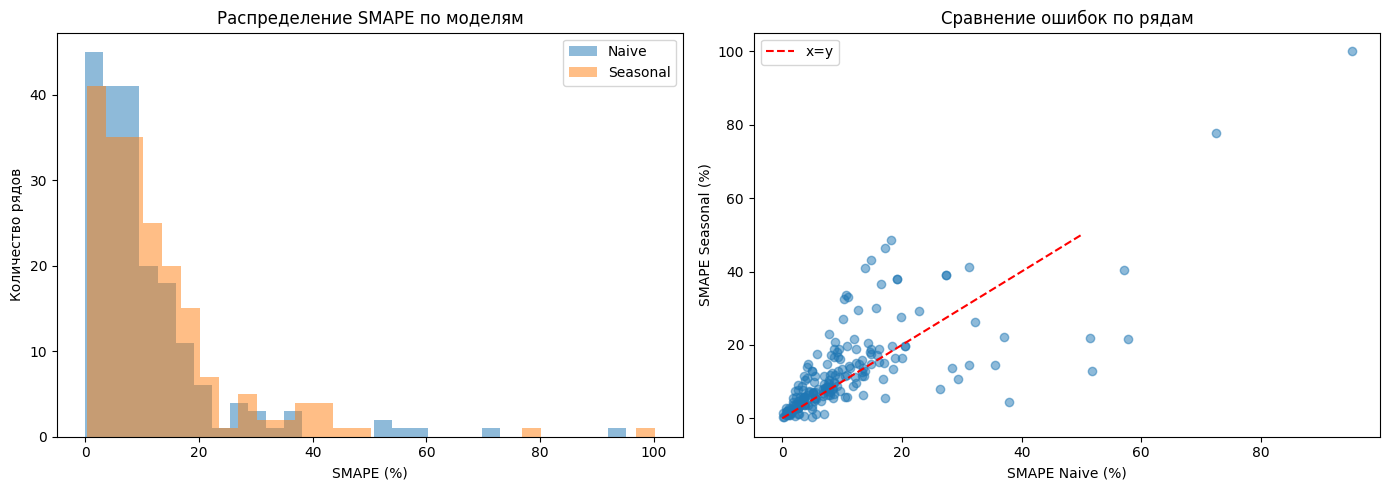

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(smape_df['smape_naive'], alpha=0.5, label='Naive', bins=30)
axes[0].hist(smape_df['smape_seasonal'], alpha=0.5, label='Seasonal', bins=30)
axes[0].set_xlabel('SMAPE (%)')
axes[0].set_ylabel('Количество рядов')
axes[0].legend()
axes[0].set_title('Распределение SMAPE по моделям')

axes[1].scatter(smape_df['smape_naive'], smape_df['smape_seasonal'], alpha=0.5)
axes[1].plot([0, 50], [0, 50], 'r--', label='x=y')
axes[1].set_xlabel('SMAPE Naive (%)')
axes[1].set_ylabel('SMAPE Seasonal (%)')
axes[1].set_title('Сравнение ошибок по рядам')
axes[1].legend()

plt.tight_layout()
plt.show()

**Выводы:** 
1) На графике распределения SMAPE по моделям видно, что для большинства рядов выигрывает Naive, т.к. распределение сильнее прижато влево, пик держится в районе от 0 до 10 %. При есть ряды, для которых и Naive, и Seasonal вообще неприемлемы (при 100% ошибка была бы такого же размера, как исходное значение). 

2) На графике сравнения ошибок по рядам большинство точек выше диагонали, слевоательно, Naive чаще выигрывает в качестве предсказания. Но есть группа рядов, хотя и меньшая по объему, для которой Seasonal действительно лучше.

# Кластеризация

В данном блоке рассматривается кластеризация рядов методом TimeSeriesKMeans с расстоянием DTW с целью анализа трансформаций рядов, разделенных на кластеры. 

Мы знаем, что ряды в датасете различаются по длине, по наличию тренда/сезонности, по уровню стабилизации дисперсии. 

Для определения числа кластеров выбрана метрика Silhouette (коэффициент силуэта) — перебор различных k (числа кластеров) с расчетом Silhouette Score — поскольку она отображает и схожесть элементов внутри одного кластера, и непохожесть различных кластеров между собой. 

Таким образом мы сможем увидеть:  
- Насколько точки внутри одного кластера похожи друг на друга (компактность)
- Насколько кластеры отличаются друг от друга (разделимость). 

Плюсы Silhouette: 
- учитывает компактность и разделимость
- работает для любой метрики, в.ч. DTW
Минусы Silhouette: 
- метод может быть вычислительно дорогим для больших данных, но адекватен для нашего датасета

Интерпретация Silhouette: оптимальным считается кол-во кластеров k, при котором метрика максимальна, т.е. значения выше 0.5 указывают на хорошую структуру кластеров.

In [92]:
from tslearn.clustering import TimeSeriesKMeans, silhouette_score
from sklearn.preprocessing import StandardScaler
from tslearn.utils import to_time_series_dataset
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

In [62]:
series_list = []

unique_series = df['series_name'].unique()

for series_name in unique_series:
    series_data = df[df['series_name'] == series_name]
    values = series_data['series_value'].values
    series_list.append(values)

print("Длина первых 10 рядов:")
for i in range(10):
    print(f"Длина ряда {i}: {len(series_list[i])}")

Длина первых 10 рядов:
Длина ряда 0: 487
Длина ряда 1: 487
Длина ряда 2: 487
Длина ряда 3: 100
Длина ряда 4: 130
Длина ряда 5: 684
Длина ряда 6: 130
Длина ряда 7: 130
Длина ряда 8: 840
Длина ряда 9: 384


Нормализуем данные перед кластеризацией (поскольку DTW будет считать расстояния в абсолютных величинах)

In [73]:
series_list_scaled = []
for i, s in enumerate(series_list):
    s_2d = s.reshape(-1, 1)
    scaler = StandardScaler()
    s_scaled = scaler.fit_transform(s_2d).flatten()
    series_list_scaled.append(s_scaled)

print(f"До: mean={series_list[0].mean():.2f}, std={series_list[0].std():.2f}")
print(f"После: mean={series_list_scaled[0].mean():.2f}, std={series_list_scaled[0].std():.2f}")

До: mean=6289.49, std=1782.82
После: mean=0.00, std=1.00


In [93]:
series_list_for_tslearn = to_time_series_dataset(series_list_scaled)
silhouette_scores = []

for k in tqdm(range(2, 11), desc="Поиск оптимального k"):
    model = TimeSeriesKMeans(n_clusters=k,
                            metric="dtw",
                            random_state=42,
                            max_iter=10,
                            n_jobs=-1)
    
    labels = model.fit_predict(series_list_for_tslearn)

    score = silhouette_score(series_list_for_tslearn, labels, metric="dtw")
    silhouette_scores.append(score)
    print(f"k={k}, silhouette={score:.4f}")

Поиск оптимального k:  11%|█         | 1/9 [03:48<30:26, 228.31s/it]

k=2, silhouette=0.4244


Поиск оптимального k:  22%|██▏       | 2/9 [06:34<22:24, 192.01s/it]

k=3, silhouette=0.3363


Поиск оптимального k:  33%|███▎      | 3/9 [09:46<19:12, 192.02s/it]

...

k=8, silhouette=0.1964


Поиск оптимального k:  89%|████████▉ | 8/9 [27:08<03:42, 222.72s/it]

k=9, silhouette=0.1919


Поиск оптимального k: 100%|██████████| 9/9 [31:58<00:00, 213.18s/it]

k=10, silhouette=0.1855


Визуализация результата подбора числа кластеров

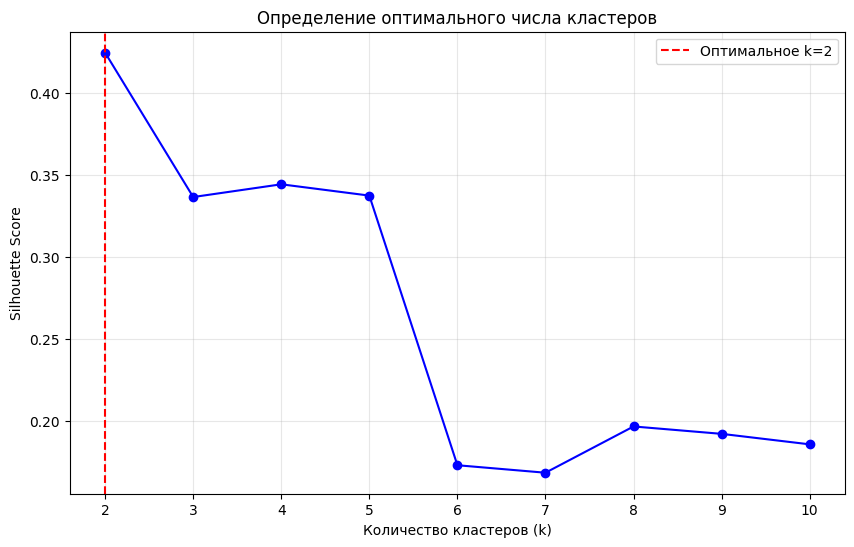


Оптимальное число кластеров: 2
Silhouette Score при k=2: 0.424


In [94]:
plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores, 'bo-')
plt.xlabel('Количество кластеров (k)')
plt.ylabel('Silhouette Score')
plt.title('Определение оптимального числа кластеров')
plt.grid(True, alpha=0.3)

best_k = range(2, 11)[np.argmax(silhouette_scores)]
plt.axvline(x=best_k, color='r', linestyle='--', label=f'Оптимальное k={best_k}')
plt.legend()
plt.show()

print(f"\nОптимальное число кластеров: {best_k}")
print(f"Silhouette Score при k={best_k}: {max(silhouette_scores):.3f}")

Посмотрим, какие ряды попали в кластеры

In [96]:
final_model = TimeSeriesKMeans(n_clusters=2,
                              metric="dtw",
                              random_state=42,
                              max_iter=10,
                              n_jobs=-1)

final_labels = final_model.fit_predict(series_list_for_tslearn)

cluster_df = pd.DataFrame({
    'series_name': df['series_name'].unique(),
    'cluster': final_labels
})

print("Распределение рядов по кластерам:")
print(cluster_df['cluster'].value_counts().sort_index())

Распределение рядов по кластерам:
cluster
0     76
1    124
Name: count, dtype: int64


In [101]:
for i in range(10):
    series_name = df['series_name'].unique()[i]
    cluster = cluster_df[cluster_df['series_name'] == series_name]['cluster'].values[0]
    print(f"{series_name}: кластер {cluster}")

T1: кластер 0
T2: кластер 0
T3: кластер 1
T4: кластер 0
T5: кластер 0
T6: кластер 1
T7: кластер 0
T8: кластер 1
T9: кластер 0
T10: кластер 0


Посмотрим на примеры рядов из получившихся кластеров

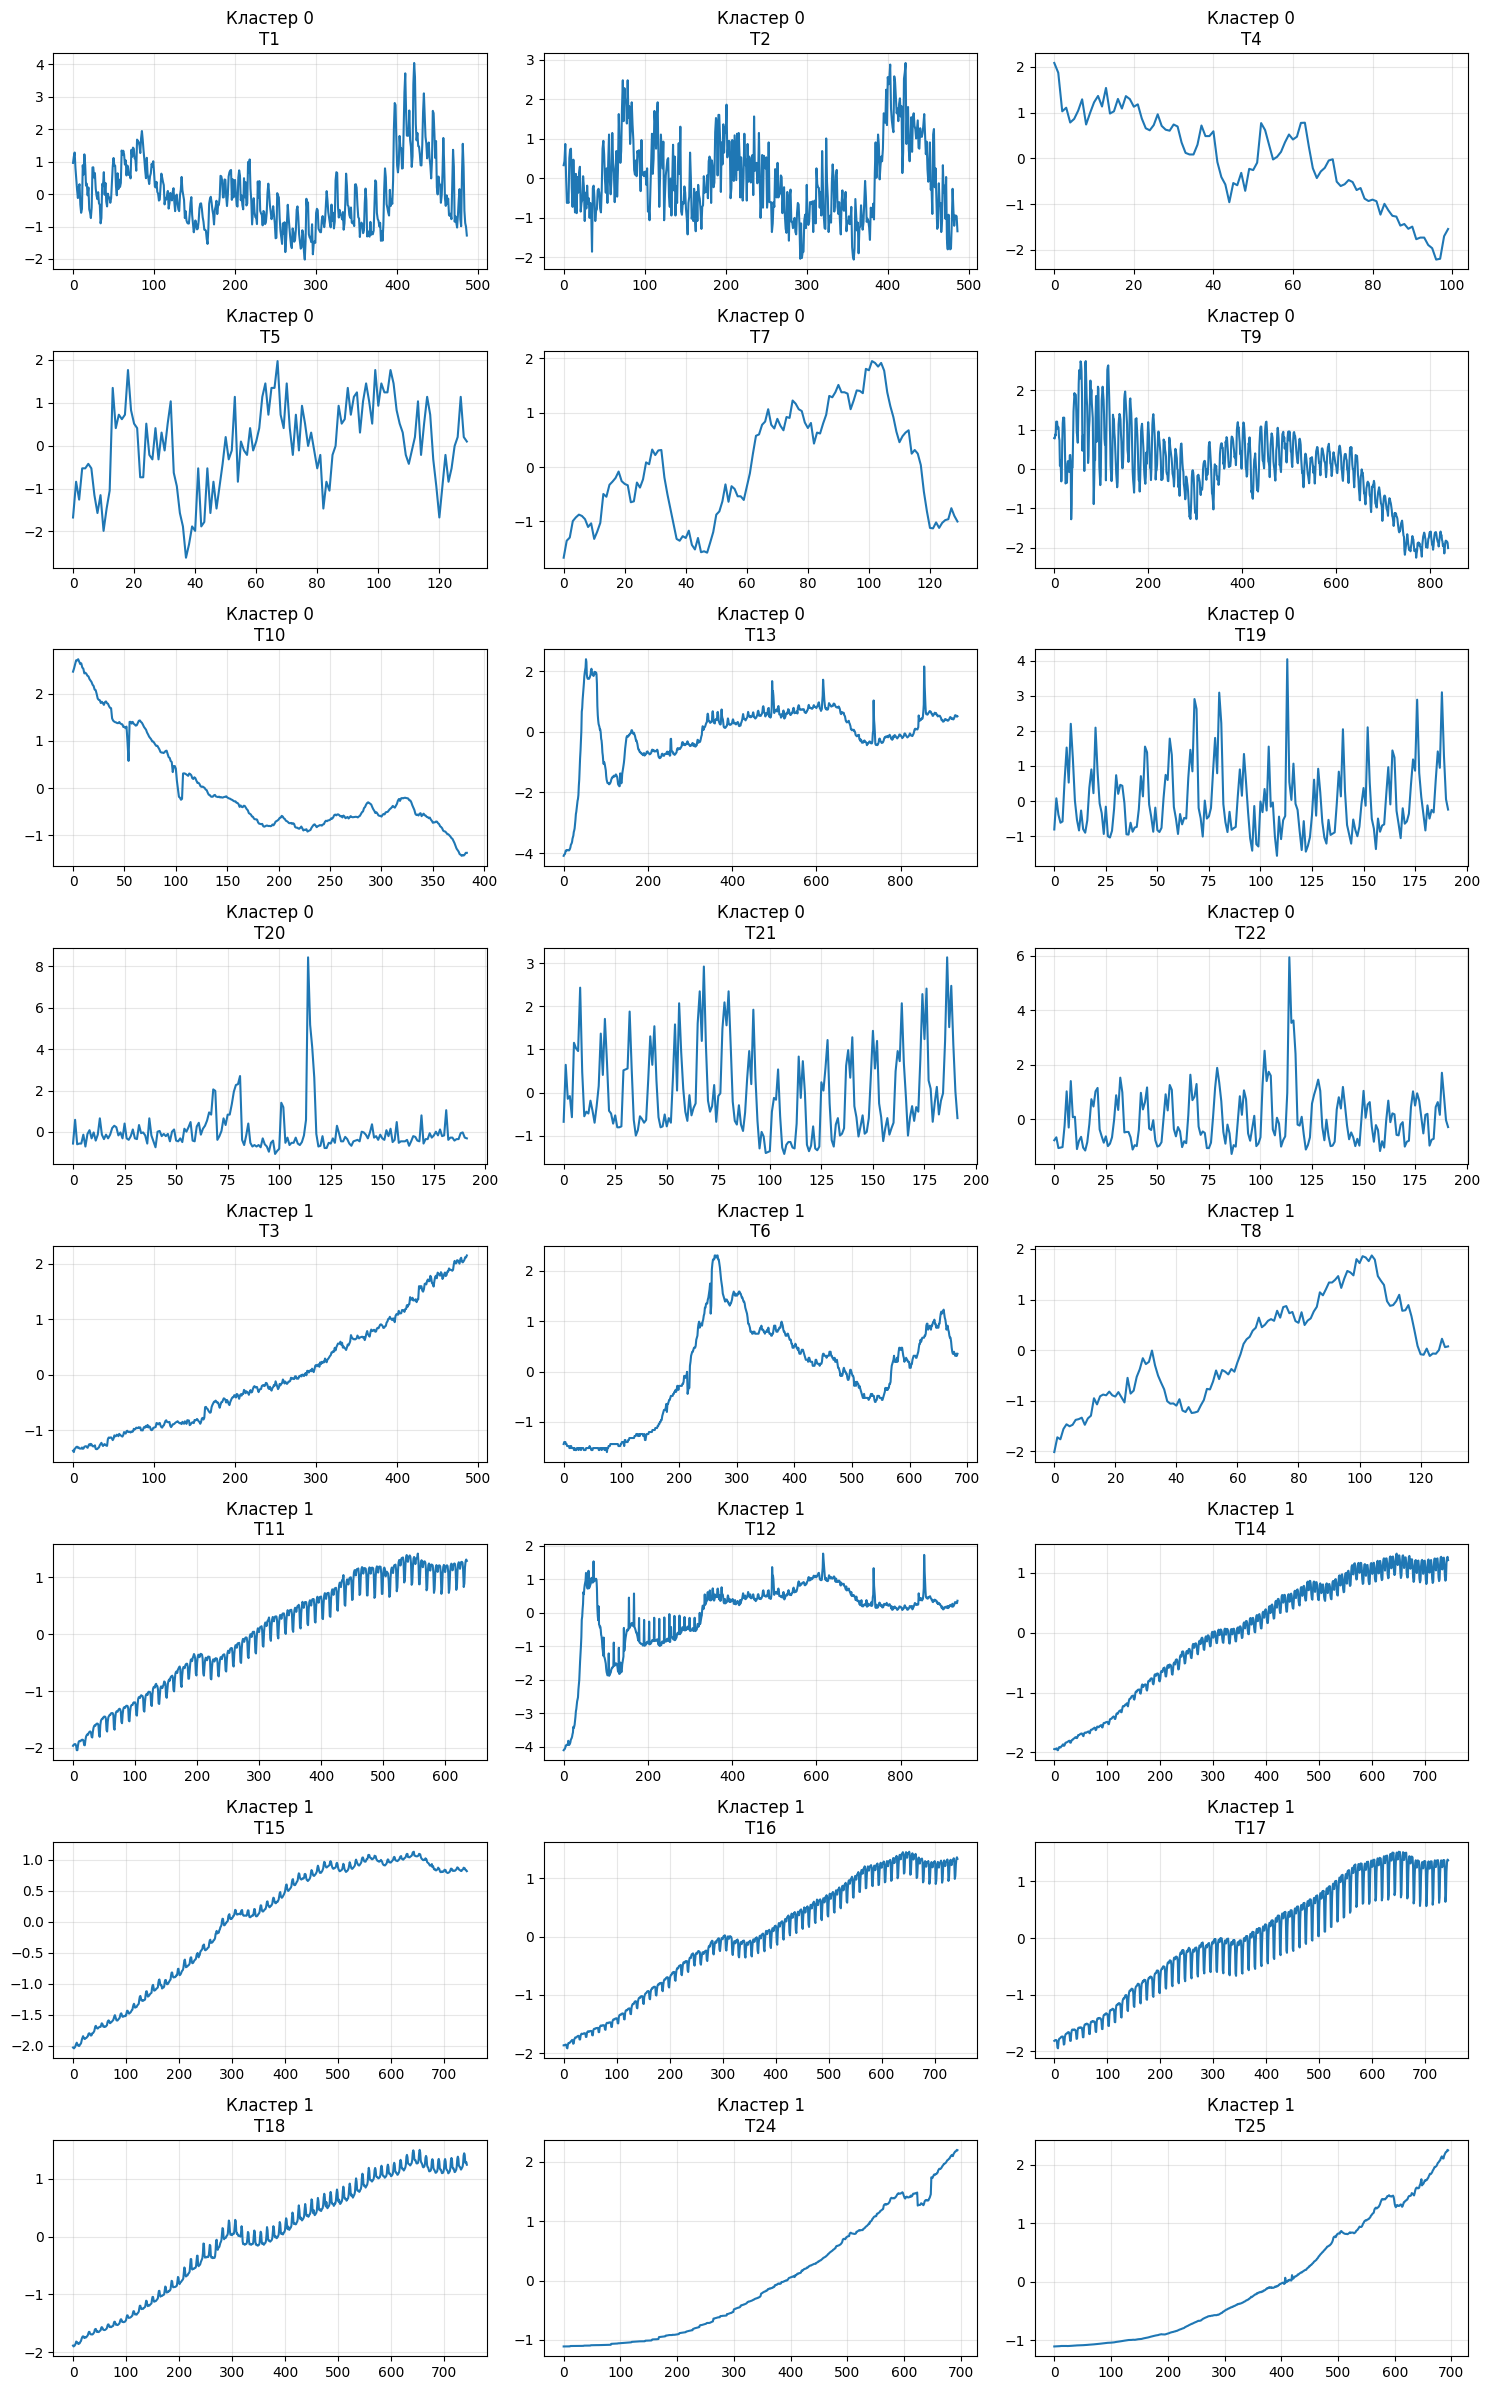

In [ ]:
fig, axes = plt.subplots(16, 3, figsize=(15, 48))
title_colors = {0: 'darkred', 1: 'darkblue'}

for cluster in [0, 1]:
    cluster_mask = cluster_df['cluster'] == cluster
    cluster_positions = np.where(cluster_mask)[0][:24]
    
    for i, pos in enumerate(cluster_positions):
        row = cluster * 8 + i // 3
        col = i % 3
        
        axes[row, col].plot(series_list_scaled[pos], color=title_colors[cluster], alpha=0.7)
        axes[row, col].set_title(f'Кластер {cluster}\n{cluster_df.iloc[pos]["series_name"]}', 
                                color=title_colors[cluster])
        axes[row, col].grid(True, alpha=0.3)
        
    for j in range(len(cluster_positions), 24):
        row = cluster * 8 + j // 3
        col = j % 3
        fig.delaxes(axes[row, col])

plt.suptitle('Представители кластеров (по 24 ряда из каждого)', fontsize=16, y=0.95)
plt.tight_layout()
plt.show()

**Выводы:** Судя по примерам, кластеризация разделила ряды по типу динамики.  
- Кластер 0: стационарность или слабый нисходящий тренд, ряды разнородные
- Кластер 1: выраженный восходящий тренд

Дополнительно визуализируем получившиеся кластеры, применив t-SNE

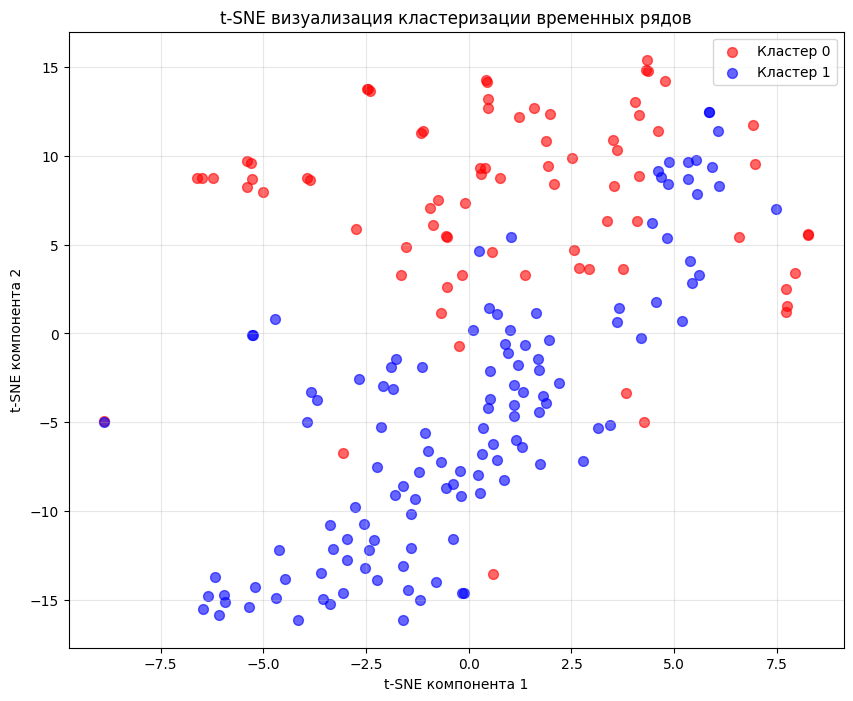

In [103]:
from sklearn.manifold import TSNE

min_length = min([len(s) for s in series_list_scaled])
X_tsne = np.array([s[:min_length] for s in series_list_scaled])

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne_result = tsne.fit_transform(X_tsne)

plt.figure(figsize=(10, 8))
colors = ['red', 'blue']
for cluster in [0, 1]:
    mask = cluster_df['cluster'] == cluster
    plt.scatter(X_tsne_result[mask, 0], 
                X_tsne_result[mask, 1],
                c=colors[cluster],
                label=f'Кластер {cluster}',
                alpha=0.6,
                s=50)
plt.xlabel('t-SNE компонента 1')
plt.ylabel('t-SNE компонента 2')
plt.title('t-SNE визуализация кластеризации временных рядов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Выводы:** кластер 1 хорошо выделен, точки сидят компактно в одной области, ряды в этом кластере действительно похожи друг на друга. Кластер 0 выделен плохо, ряды сильно разбросаны, внутри этого кластера ряды могут быть очень разными по форме.